# Computational Learning Theory

Several fundamental questions arise as soon as we move from designing a single learning algorithm to **studying learning as a scientific discipline**. When we observe that a neural network can classify images or that a decision tree can predict credit risk, we are naturally led to deeper questions that go **beyond empirical performance** on a benchmark dataset. We want to **understand what is possible in principle, what is feasible in practice, and what limitations are unavoidable**.

Among the central questions are the following. **Which concepts can be learned efficiently**, meaning with computational resources that grow reasonably with the size of the problem? **Which concepts are inherently hard to learn**, regardless of clever algorithmic tricks? **How many training examples are required** before a learner can generalize reliably beyond the observed data? And finally, is there **a general mathematical model that captures the essence of learning from examples**, independently of the specific algorithm being used?

## Probably Approximately Correct

To address these questions rigorously, we need a **formal framework**. One of the most influential models in computational learning theory is the [**Probably Approximately Correct** (PAC) framework](./papers/(1984)%20-%20A%20theory%20of%20the%20learnable.pdf). The key idea is to shift the focus from fitting the training data to **guaranteeing performance on unseen data**, under explicit probabilistic assumptions. This shift **from empirical performance to formal guarantees** is what turns machine learning into a **theory of learning**, not merely a **collection of algorithms**.

### Problem proposition

We consider the problem of **learning a target concept** (namely the mapping from inputs to outputs):

$\displaystyle c : X \to Y, \qquad c \in C$

where X is the **instance space** of all possible inputs over which the target function is defined. An element x of this space represents a single example or instance, and Y is the **value space** of possible outputs (labels). This target concept is **unknown** and it belongs to a known **concept class** C:

$\displaystyle C = \{c_1, c_2, \dots\}$

Instead we can only access information about the target concept through a **finite sample of examples** T (training set), which consists of pairs of input instances and their corresponding outputs according to the target concept:

$\displaystyle T = \{(x_1, c(x_1)), \dots, (x_m, c(x_m))\}$

As an example, consider the problem of email spam detection. In this case, the concept class could be the set of all possible functions that map an email to either spam or not spam. The true target concept is the real, but unknown, rule that perfectly separates spam from legitimate emails. Of course, this rule is not explicitly given to us. Instead, we observe a finite set of emails (represented through features such as word frequencies, presence of links, sender metadata, etc.) correctly labeled as spam or not spam according to the target concept.

A **learner** (an algorithm) L has to search for a solution, however it does not search over the entire concept class C, which might be astronomically large. Instead, it selects a **hypothesis** h from a predefined **hypothesis space** H of candidate functions:

$\displaystyle H = \{h_1, h_2, \dots\}$

In the spam detection example, the hypothesis space could be defined as the set of all linear classifiers over the chosen features, or the set of all decision trees up to a certain depth, or the set of neural networks with a fixed architecture. The goal of the learner is to exploit the training set T to find an hypothesis h of H that **approximates** the target concept c of C **"well enough"** to make accurate predictions on new, unseen instances. In general, H need not coincide with the concept class C, e.g., the true target concept may or may not belong to the learner’s hypothesis space. This distinction is important. The learner is **constrained by the expressive power** of H: if it is **rich enough**, it may contain a hypothesis very close to the true concept, otherwise if it is **too restricted** (for example, only linear classifiers when the true decision boundary is highly nonlinear), then the learner may never approximate c well.

We assume that examples are **drawn at random** from the instance space according to an **underlying probability distribution** D, which is in general unknown to the learner:

$\displaystyle D : X \to [0,1], \qquad \sum_{x \in X} D(x) = 1$

In the spam-detection example, the distribution captures how emails are generated "in the wild": which senders appear, which topics are common, how frequently certain words occur, how often links show up, and so on. Crucially, we assume that this distribution is **stationary**, in order to encode the idea that the environment generating the data **remains stable** while the learner is trying to infer the target concept:

$x_t \sim D \quad \text{for } t = 1, 2, \dots$

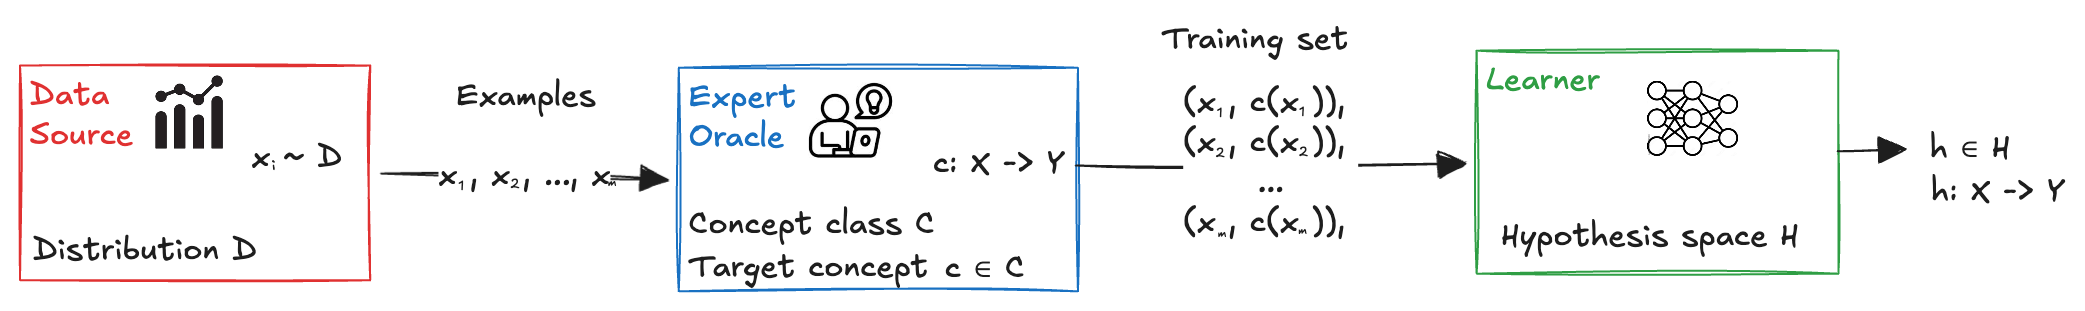

If the distribution were allowed to drift during learning, then past observations might no longer be representative of future ones, and generalization would become ill-posed. In contrast, stationarity ensures that the statistical regularities extracted from the training sample remain relevant for future predictions. Intuitively, **learning relies on the principle that the future resembles the past**, at least in distribution. The stream of emails we will face tomorrow should be governed by essentially the same statistical law as the stream we used to train the model today. Under this assumption, drawing a training set is informative about the future. Without stationarity (think of spammers abruptly changing vocabulary, phishing tactics, or sender infrastructure) the trained classifier might suddenly be facing a different distribution, and then low training error would not imply anything about performance on the new stream.

For simplicity, we restrict our discussion to the case of **learning Boolean-valued concepts** (classification problem) from **noise-free training data**, meaning that every example provided to the learner is correct. This assumption allows us to focus on the **structural aspects** of learnability without introducing additional complications due to label corruption:

$\displaystyle c : X \to \{0,1\}, \qquad c \in C$

Nevertheless, many of the theoretical results extend naturally to more general settings, including the case of real-valued target functions (regression problems) and, in several instances, to scenarios involving noisy data.

### Generalization and training errors

The purpose of the learnenr is not merely to fit the observed training data, but to **approximate the unknown target concept** in a way that remains valid on unseen examples. For this reason, we need a precise and quantitative **notion of performance**. The natural measure is the **true (or generalization) error**, defined with respect to both the target concept and the underlying data distribution:

$\displaystyle e_{D}(h) = P_{x \sim D}[h(x) \neq c(x)]$

This quantity measures the probability that the hypothesis **disagrees** with the true concept on a randomly drawn instance. Notice that the evaluation is performance **over the entire instance distribution**, not merely over the training set. This is essential since we care about how the learned hypothesis performs on **new, unseen data**, not just on the examples used to construct it. In the running spam-detection example, the generalization error is the long-run fraction of incoming emails that would be incorrectly labeled as spam or non-spam.

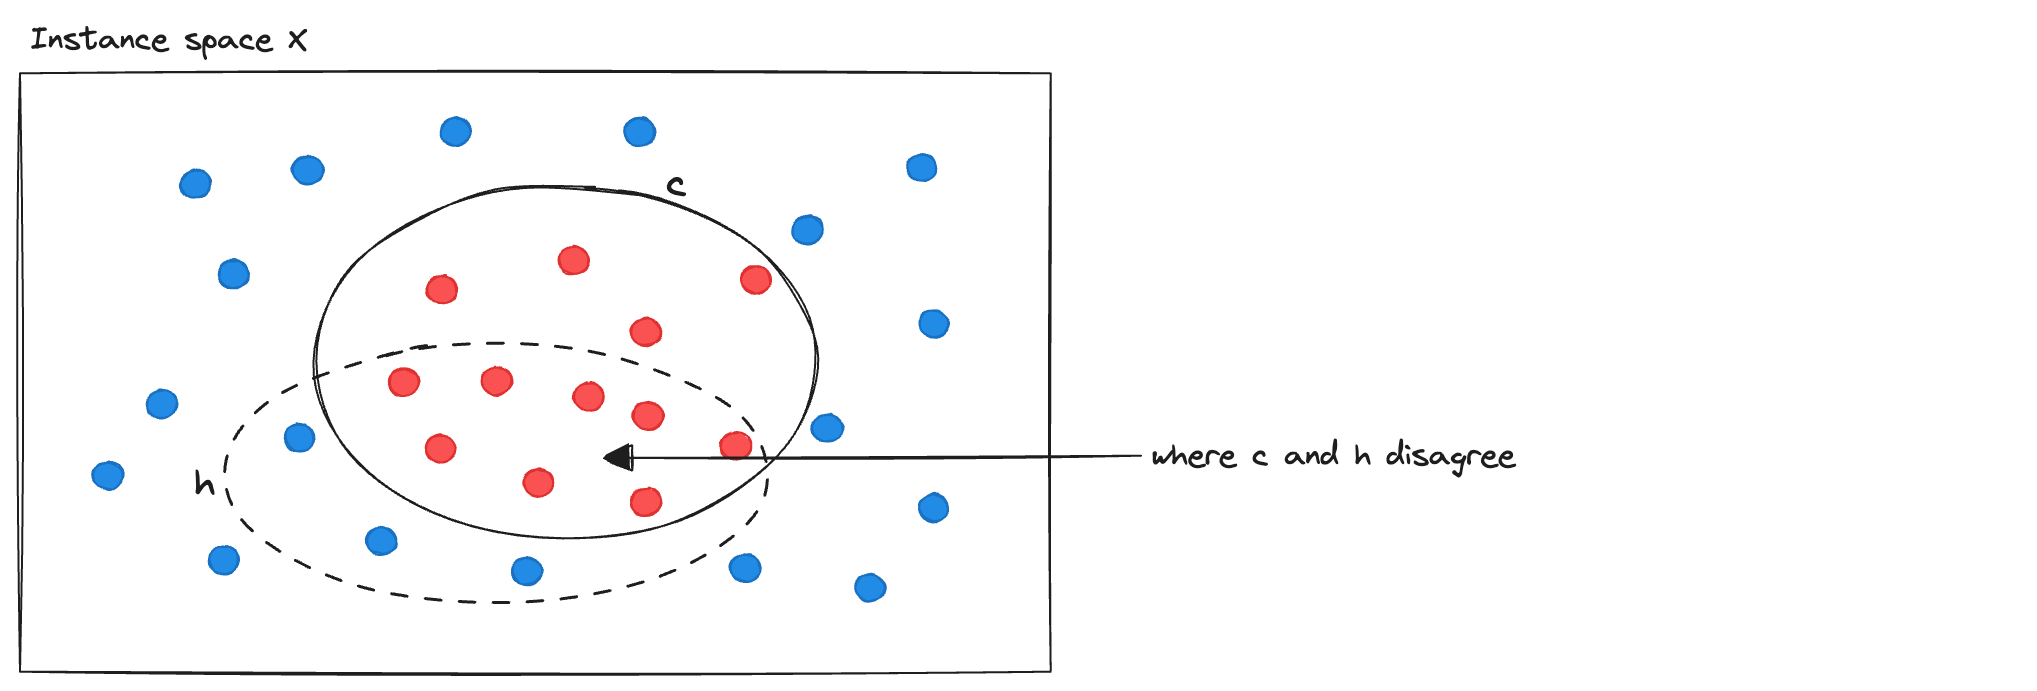

Notice that the evaluation **depends critically on the underlying probability distribution**  If the distribution D is **uniform** over X then the true error simply corresponds to the fraction of the entire instance space on which the hypothesis h and the target concept c disagree. In this case, every region of X contributes equally to the error: disagreement on any subset counts proportionally to its size. However, in general, the distribution D **need not be uniform**. In many practical situations, certain instances occur much more frequently than others. In the spam-detection example the distribution is far from uniform. Some types of emails are extremely common (e.g., routine newsletters, marketing campaigns, transactional confirmations), while others are rare. The distribution D assigns high probability mass to frequently occurring patterns of emails and very little mass to unusual or exotic ones. Suppose the classifier disagrees with the true concept only on a small set of bizarre email patterns that almost never appear in practice. Even if this disagreement region is large in a geometric sense, the error may still be negligible. Conversely, if h makes mistakes on a very common type of spam (for instance, phishing emails that contain certain high frequency keywords) then even a small disagreement region may carry large probability mass, and the generalization error will be correspondingly large. The key point is therefore conceptual and fundamental: what matters is not the geometric size of the disagreement region, but its probability mass under D. Learning theory is thus inherently **distribution-dependent**. Performance is defined relative to how data are actually generated, not relative to abstract agreement over the entire instance space.

However, the generalization error **is not directly observable** to the learner. The distribution D is unknown, and only a finite sample of examples is available. The learner can therefore compute only the error over the training set:

$\displaystyle e_{T}(h) = P_{x \in T}[h(x) \neq c(x)]$

which we call the **training error**, i.e., the fraction of training examples misclassified by the hypothesis. In the running spam-detection example, this corresponds to the proportion of labeled emails in the training set that the classifier misclassifies. If this error is zero, the classifier perfectly fits the observed emails. But **this tells us nothing**, by itself, about how it will behave on tomorrow’s incoming emails drawn from the real-world distribution. Here lies **the central tension in learning theory**. The learner selects a hypothesis based solely on the training data, yet it is evaluated according to its performance on the entire distribution. This gap between what is observable (training performance) and what truly matters (generalization performance) is the core difficulty of statistical learning.

Much of the theoretical analysis of learning complexity revolves around the following question: **how likely is it that the observed training error provides a misleading estimate of the true error?** In probabilistic terms, we seek bounds of the form:

$\displaystyle P[ \left| e_T(h) - e_D(h) \right| > \varepsilon ]$

and we want this probability to be small when the sample size is sufficiently large. Understanding when and why empirical performance reliably reflects generalization performance lies at the heart of statistical learning theory.

### Learnability

The central objective of learning theory is to **characterize which concept classes can be learned reliably**, using a **reasonable number of training examples** and a **reasonable amount of computation**. In other words, we seek conditions under which a learner can produce a hypothesis whose performance on future data is provably good, without requiring infeasible amounts of data or exponential-time search. At first glance, one might be tempted to impose a **very strong requirement**, that the learner output a hypothesis with **zero error**:

$\displaystyle e_{D}(h) = 0$

In the probabilistic framework we are considering, however, such a demand is generally **unrealistic**. First, the learner observes only a finite sample (the training set) not the entire instance space X and even if the hypothesis perfectly fits the training data:

$\displaystyle e_T(h) = 0$

there may exist many distinct hypotheses consistent with the sample and **nothing guarantees that the selected one coincides exactly with the true target concept on unseen instances**. Second, because the examples are drawn randomly from the distribution, there is always **a nonzero probability that the training sample is misleading**. A rare but important region of the instance space may simply not appear in the training data. For example a rare but highly important type of phishing email might not appear in the training set at all. Any classifier trained solely on that sample may misclassify such emails, even if it achieves zero training error. The issue is not the size of the instance space, but the fact that the sample **represents only a random slice of the underlying distribution**.

For these reasons, learning theory **relaxes the requirement of exact identification**, instead of demanding zero error, we require that the hypothesis have **small error** (**accuracy parameter**):

$\displaystyle e_D(h) \le \varepsilon \quad \varepsilon \in (0,1)$

And instead of requiring success for every possible training sample, we require that this performance guarantee **hold with high probability** (**confidence parameter**) over the random draw of the sample:

$\displaystyle P[ e_D(h) \le \varepsilon] \ge 1 - \delta \quad \delta \in (0,1)$

This leads to the notion of **Probably Approximately Correct (PAC) learning**: a concept class is considered **learnable** if there exists a learner able to achieve an hypotesis with **arbitrarily high confidence** and **arbitrarily small error**. Moreover, the learner must satisfy these guarantees **efficiently**. It is not enough that small error can eventually be achieved, both the number of training examples and the running time of the learning algorithm must **grow at most polynomially** in the strength of the requirements:

$\displaystyle \frac{1}{\varepsilon}, \quad \frac{1}{\delta}, \quad \text{size}(c), \quad \text{size}(x)$

Here, size(c) denotes the **complexity of representing the target concept**. Concretely, once a representation language for concepts has been fixed (for instance, decision trees, neural networks, or programs) this quantity measures the length or structural complexity of the specific concept (the number of nodes in a tree, the number of parameters in a network, the number of lines of code in a program, and so on). Similarly, size(x) denotes the **complexity of representing an instance** x of X, such as its dimensionality, number of features, or bit-length encoding.

Requiring polynomial running time ensures that the learner is not only **statistically sound** but also **computationally tractable**. This efficiency requirement has an important implicit consequence: it constrains the sample complexity as well. If the learner must process each training example in at least constant time, then polynomial running time immediately implies that only a polynomial number of training examples can be required. In this sense, computational complexity and sample complexity are tightly linked within the PAC framework.

In essence, PAC learning formalizes the principle that learning is feasible when two conditions hold simultaneously: **good hypotheses can be found efficiently**, and a **limited amount of data suffices** to identify them with high confidence.

## Complexity in finite hypothesis spaces

We define the sample complexity as the function that describes **how the number of required training examples grows with the intrinsic parameters of the learning problem**. Formally, it characterizes how large the sample size m must be in order to guarantee the a certain level of generalization error with high confidence:

$\displaystyle m = m\!\left(\varepsilon, \delta, \mathrm{size}(c), \mathrm{size}(x)\right)$

We need that this quantity grows at most polynomially in these parameters. This notion is particularly important in practice because, in many real-world applications, **the primary bottleneck is not computational power but the availability of labeled data**. In the spam-detection example, for instance, training a classifier may require thousands or millions of labeled emails, and obtaining accurate labels can be **costly**, **time-consuming**, or **privacy-sensitive**. Even if training can be performed quickly on modern hardware, insufficient data may prevent the learner from achieving low generalization error.

### Version space

For a broad and important class of algorithms, called consistent learners, one can derive **general bounds** on sample complexity. A learner is said to be **consistent** if it always returns a hypothesis that perfectly fits the observed training data:

$\displaystyle e_{T}(h) = 0$

This means that for every labeled example, the hypothesis agrees with the target concept:

$\displaystyle \forall i \in \{1,\dots,m\}, \qquad h(x_i) = c(x_i)$

We introduce the notion of **version space** as the set of all hypotheses in H that are consistent with the observed training examples:

$\displaystyle \mathrm{VS}_{H,T} = \{\, h \in H : e_T(h)=0 \,\}$

In spam example, the version space consists of all classifiers that correctly label every email in the training set. Different hypotheses in this set may behave differently on unseen emails, even though they agree perfectly on the observed sample.

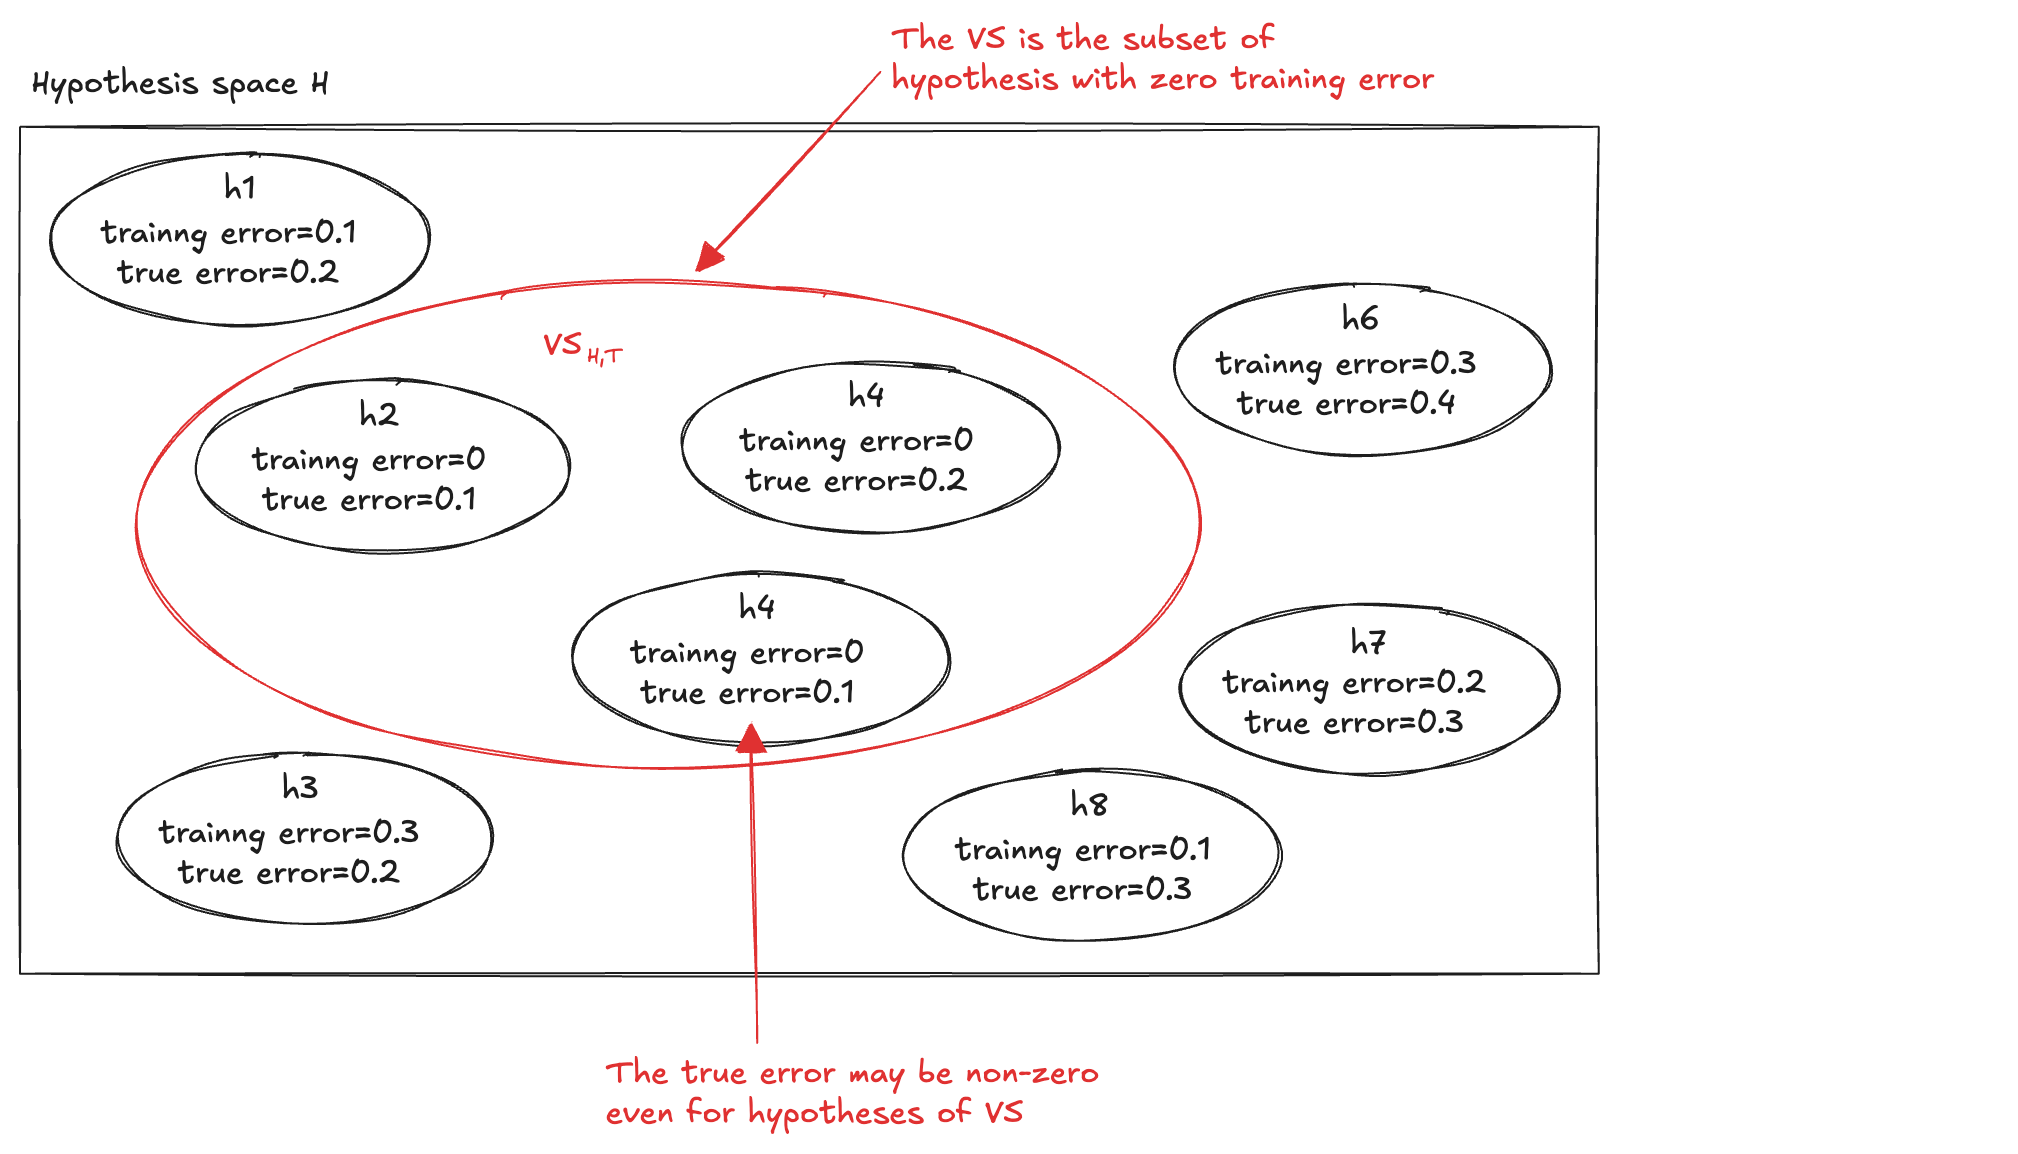

Intuitively, the version space represents **the learner’s remaining uncertainty after observing the sample**. Before seeing any data, every hypothesis in H is a possible candidate for the true target concept. As training examples are observed, inconsistent hypotheses are progressively eliminated. In the running spam-detection example, this intuition becomes very concrete. Before observing any labeled emails, the learner considers many possible classifiers as plausible explanations of what "spam" means. Some of these candidate classifiers may behave reasonably on typical emails, while others might misclassify large portions of real-world traffic. At this stage, the learner has no way of distinguishing between them. Each labeled email acts as a filter. Whenever a classifier assigns the wrong label to a training email, it is discarded. As more labeled emails are observed, entire portions of the hypothesis space are progressively eliminated. The version space shrinks: only those classifiers that correctly classify all observed emails remain viable.

The  objective is to drive the version space to the point **where it contains no "unacceptable" hypotheses**, where every hypothesis that remains has small true error. We say the version space is **exhausted** when:

$\displaystyle \forall h \in \mathrm{VS}_{H,T} \quad e_{D}(h) < \varepsilon$

because once this condition holds any hypothesis output by a consistent learner is guaranteed to have a small true error, thus the sample-complexity question can be rephrased: **how large must the random training sample be so that, with high probability, all hypotheses in the version space are good?** On the example, how many labeled emails are needed before every classifier still consistent with the training data will also perform well on future incoming mail.

### Bounding the probability of version space exhaustion

Only an observer who knew the true target concept could determine with certainty whether the version space has been exhausted. **The learner itself cannot directly verify this**, because exhaustion is defined in terms of the unknown distribution and the true error. However, although we cannot check exhaustion deterministically, we can **bound the probability** that the version space is not yet exhausted after observing a given number of training examples, provided that the **hypothesis space is finite**.

After observing m independent training examples, the probability that the version space still contains at least one "bad" hypothesis is bounded by:

$\displaystyle P[\mathrm{VS}_{H,T} \text{ not exhausted}] \;\le\; |H|\, e^{-\varepsilon m}$

The intuition is that any hypothesis with large true error has a non-negligible probability of being contradicted by a randomly drawn example. The probability that such a hypothesis survives m independent examples without ever being contradicted decays exponentially in m. Therefore, **as the sample size increases, the probability that any unacceptable hypothesis remains in the version space decreases exponentially fast**. This exponential decay is the fundamental mechanism underlying sample complexity bounds in the finite-hypothesis setting. In the spam-detection example, this result has a very concrete interpretation: more emails we observe adn more becomes unlikely that a classifier that performs poorly on real-world traffic could continue to agree with all observed labels purely by chance. We can prove this result by considering all the k bad hypotheses in H:

$\displaystyle h_1, h_2, \ldots, h_k$ 

The true error of each of these hypotheses exceeds the limit:

$\displaystyle e_D(h_i) > \varepsilon$

We can rewrite this condition in terms of the probability of disagreement with the target concept on a random example:

$\displaystyle P_{x \sim D}[h_i(x) \neq c(x)] > \varepsilon$

Consequently, the probability that the hypothesis agrees with the target concept is:

$\displaystyle P_{x \sim D}[h_i(x) = c(x)] < 1 - \varepsilon$

Since training examples are drawn independently, the probability that the hypothesis is consistent with all m examples is:

$\displaystyle P_{T \sim D^m}[e_T(h_i) = 0] < (1 - \varepsilon)^m$

There are k such bad hypotheses, by the union bound (if there are many different ways for an event to happen, then the probability that at least one of them happens is no larger than the sum of their individual probabilities) the probability that at least one of them survives all m examples is at most:

$\displaystyle P_{T \sim D^m}[\exists \, i \in \{1,\dots,k\} : e_T(h_i) = 0] < k (1 - \varepsilon)^m$

Since the hypothesis space is finite:

$\displaystyle k \le |H|$

Thus the probability that the version space is not exhausted is bounded by:

$\displaystyle P[\mathrm{VS}_{H,T} \text{ not exhausted}] \;\le\; |H|\, (1 - \varepsilon)^m$

Finally, using the standard inequality

$\displaystyle 1 - \varepsilon \le e^{-\varepsilon} \quad 0 \leq \varepsilon \leq 1$

we can rewrite the bound as:

$\displaystyle P[\mathrm{VS}_{H,T} \text{ not exhausted}] \;\le\; |H| e^{-\varepsilon m}$

which is the desired exponential bound.

### Required Sample Size

The previous result provides a bound on the probability that the training sample fails to eliminate all "bad" hypotheses for any consistent learner operating over a finite hypothesis space H. We can now invert this bound to determine **how many training examples are required** in order to make this probability of failure smaller than a desired confidence. Starting from

$\displaystyle |H| e^{-\varepsilon m} \leq \delta $

and solving for m, we obtain:

$\displaystyle m \geq \frac{1}{\varepsilon} \left( \ln |H| + \ln \frac{1}{\delta} \right)$

We can implement this formula in Python in order to make some numerical examples:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sample_bound_consistent(epsilon, delta, H_size):
    return (1 / epsilon) * (np.log(H_size) + np.log(1 / delta))

This number of examples is sufficient to guarantee that any consistent learner will output a hypothesis that is **probably** (with probability at least $1-\delta$) **approximately** (within error $\varepsilon$) **correct**. Several qualitative observations follow from this bound:

- The required number of examples grows linearly in $1/\varepsilon$: demanding higher accuracy (smaller $\varepsilon$) increases the sample size proportionally.
- It grows logarithmically in $1/\delta$: increasing the confidence level (making $\delta$ smaller) requires only a mild, logarithmic increase in data.
- It grows logarithmically in |H|: larger hypothesis spaces require more data, but only logarithmically.

This last dependence is particularly revealing. Although the bound depends only logarithmically on the hypotesis space size, this size often grows exponentially with the number of attributes. For example, in a Boolean hypothesis spaces, the number of possible functions over d binary attributes is on the order of 2^2^d. Consequently, it may still scale exponentially in the number of attributes.This observation captures a **central difficulty in high-dimensional learning**: increasing the number of attributes dramatically enlarges the space of possible classifiers, and more data is needed to rule out incorrect ones. At the same time, this bound can be a **substantial overestimate**. It treats all hypotheses as equally independent possibilities and applies a crude union bound. In many cases, the effective complexity of the hypothesis class is much smaller than its cardinality suggests. This insight motivates more refined complexity measures which allow us to derive sharper and more informative sample complexity bounds. 

To build intuition for how this bound behaves in practice, we can evaluate it for several combinations of hypothesis space size, accuracy, and confidence. The table below reports the required number of training examples for representative parameter choices, while the two plots that follow visualize the key dependencies: the first confirms that the sample size grows linearly with the inverse accuracy, and the second reveals the logarithmic dependence on the hypothesis space size, showing that even a dramatic increase in the size of the hypothesis space demands only a modest amount of additional data:

In [2]:
print("=== Sample complexity for consistent learners ===\n")
print(f"{'|H|':>12}  {'ε':>8}  {'δ':>8}  {'m ≥':>10}")
print("-" * 44)
for H_size in [100, 1_000, 10_000, 1_000_000]:
    for eps in [0.1, 0.05, 0.01]:
        m = sample_bound_consistent(eps, 0.05, H_size)
        print(f"{H_size:>12,}  {eps:>8}  {0.05:>8}  {m:>10.0f}")
    print()

=== Sample complexity for consistent learners ===

         |H|         ε         δ         m ≥
--------------------------------------------
         100       0.1      0.05          76
         100      0.05      0.05         152
         100      0.01      0.05         760

       1,000       0.1      0.05          99
       1,000      0.05      0.05         198
       1,000      0.01      0.05         990

      10,000       0.1      0.05         122
      10,000      0.05      0.05         244
      10,000      0.01      0.05        1221

   1,000,000       0.1      0.05         168
   1,000,000      0.05      0.05         336
   1,000,000      0.01      0.05        1681



The following plot shows how the required number of training examples grows as a function of 1/ε for hypothesis spaces of different sizes. Notice that the relationship is perfectly linear, confirming the 1/ε dependence in the bound:

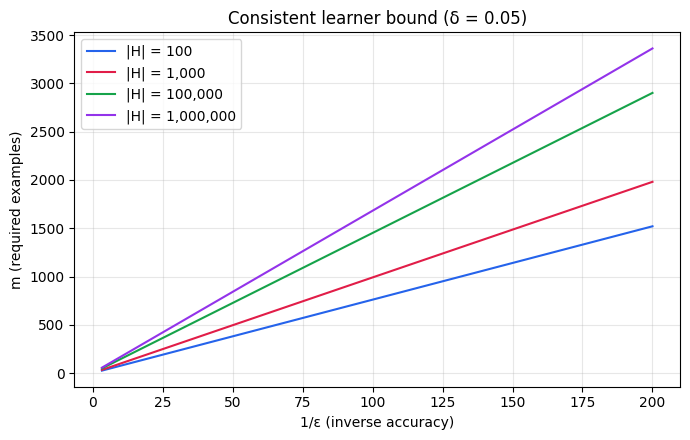

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))

epsilons = np.linspace(0.005, 0.3, 300)
delta = 0.05

for H_size, color in zip([100, 1_000, 100_000, 1_000_000],
                          ["#2563eb", "#e11d48", "#16a34a", "#9333ea"]):
    m_values = sample_bound_consistent(epsilons, delta, H_size)
    ax.plot(1/epsilons, m_values, label=f"|H| = {H_size:,}", color=color)

ax.set_xlabel("1/ε (inverse accuracy)")
ax.set_ylabel("m (required examples)")
ax.set_title(f"Consistent learner bound (δ = {delta})")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The next plot shows the same bound as a function of the hypothesis space size, on a logarithmic scale. The curves flatten out as |H| grows, confirming that the dependence is only logarithmic: doubling the size of the hypothesis space adds only a constant number of additional training examples.

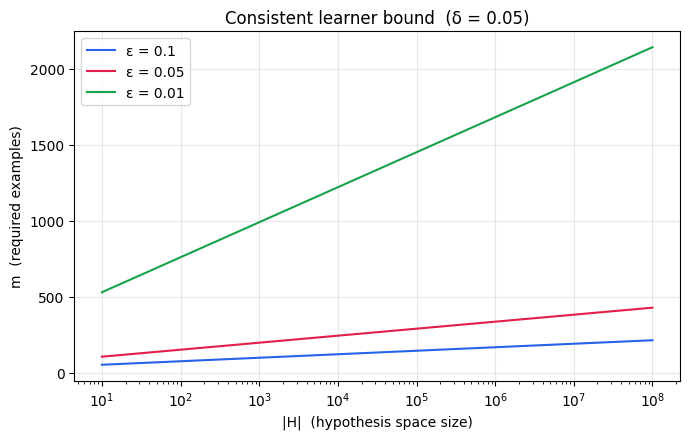

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))

delta = 0.05
H_sizes = np.logspace(1, 8, 300)

for eps, color in zip([0.1, 0.05, 0.01],
                       ["#2563eb", "#e11d48", "#16a34a"]):
    m_values = sample_bound_consistent(eps, delta, H_sizes)
    ax.plot(H_sizes, m_values, label=f"ε = {eps}", color=color)

ax.set_xlabel("|H|  (hypothesis space size)")
ax.set_ylabel("m  (required examples)")
ax.set_title(f"Consistent learner bound  (δ = {delta})")
ax.set_xscale("log")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Empirical risk minimization

Unfortunately, in the most general setting there **may be no hypothesis** that fits the labeled training sample perfectly. This is not an edge case, it is often the norm in practice. Labels may be **noisy**, the phenomenon we are modeling may be **intrinsically complex**, or our chosen hypothesis space may simply be **too restricted** to represent the true target concept exactly. In such situations, insisting on consistency (zero training error), is impossible. Still, hypotheses that make only a small number of mistakes on the training set can be highly useful. In this regime, a natural goal is to **select the hypothesis that achieves the minimum empirical error** on the observed sample. This is the **empirical risk minimization principle**:

$\displaystyle h_{\text{best}} = \arg\min_{h\in H} e_T(h)$

A learner that does not assume that the target concept is representable within H, and instead simply returns a hypothesis with minimal training error, is often called an **agnostic learner**. The term "agnostic" reflects the absence of any prior commitment about the relationship between the true labeling rule and the hypothesis class. At this point, the central issue becomes the gap between performance on the finite sample and performance on the underlying distribution. Even the empirically best hypothesis may look good on the training set simply by chance, especially when H is large. So the natural question is: **how many training examples suffice to ensure that, with high probability, the true error of the empirically best hypothesis is not much worse than its training error?** A typical guarantee takes the form:

$\displaystyle e_D(h_{\text{best}}) \le e_T(h_{\text{best}}) + \varepsilon$

This inequality formalizes the idea that empirical performance is a reliable estimate of generalization performance, up to an additive tolerance, with high probability over the random draw of the sample. Notice that the "consistent" case studied earlier is simply a special instance of this more general viewpoint. If a consistent hypothesis exists, then 

$\displaystyle e_T(h_{\text{best}}) = 0$ 

and the bound above reduces to

$\displaystyle e_D(h_{\text{best}}) \le \varepsilon$

which is exactly the kind of guarantee we derived before.

To answer the new question, we fix an hypothesis h of H and define a new variable that indicates whether h makes a mistake on a random example:

$\displaystyle z = \mathbf{1}_{\{h(x) \neq c(x)\}} \quad x \in X$

The training error can be expressed as the empirical mean of this variable over the training set:

$\displaystyle e_T(h) = \frac{1}{m}\sum_{i=1}^m z_i$

While the true error is the expectation of the same variable:

$\displaystyle e_D(h) = \Pr(h(x) \neq c(x)) = \mathbb{E}[z]$

So the quantity we care about, the difference between true error and training error, can be rewritten as the empirical mean minus expectation:

$\displaystyle e_D(h) - e_T(h) = \mathbb{E}[z] - \frac{1}{m}\sum_{i=1}^m z_i$

At this point **Hoeffding’s inequality** (a fundamental result in probability theory) applies directly, because it is precisely a bound on how much an empirical mean can deviate from its expectation. Concretely, it gives:

$\displaystyle P[e_D(h) > e_T(h) + \varepsilon] = P\left[\mathbb{E}[Z_i] - \frac{1}{m}\sum_{i=1}^m Z_i > \varepsilon \right] \le e^{-2m\varepsilon^2}$

Hoeffding’s inequality bounds the probability that a fixed hypothesis h has a misleadingly optimistic training error (i.e. that its empirical error underestimates its true error) by more than a specified margin.

However, an agnostic learner does not commit to a fixed h in advance: it chooses the hypothesis after seeing the sample, by searching over H. For this reason, we must control the probability that there exists at least one hypothesis in H whose training error is overly optimistic. Using a union bound over all h of H, we obtain:

$\displaystyle P\left[\exists\, h \in H: \ e_D(h) > e_T(h) + \varepsilon \right] \;\le\; |H|\, e^{-2m\varepsilon^2}$

We ask how many example suffice to hold this probability below some desired level, we obtain the following bound:

$\displaystyle|H|\, e^{-2m\varepsilon^2} \le \delta$

then solving for m yields the sufficient sample size

$\displaystyle m \ge \frac{1}{2\varepsilon^2}\left(\ln|H|+\ln\frac{1}{\delta}\right)$

In Python:

In [6]:
def sample_bound_agnostic(epsilon, delta, H_size):
    return (1 / (2 * epsilon**2)) * (np.log(H_size) + np.log(1 / delta))

This result generalizes the earlier consistent-case bound to the agnostic setting: the learner still selects the hypothesis with minimum training error, but that minimum may be strictly positive. The price of this greater generality is that the required number of examples now grows like 1/ε², rather than linearly in 1/ε. We can compare these two bounds numerically to see how significant this difference is. The following table and plot make this comparison concrete. The table shows side-by-side the sample sizes required by the consistent and agnostic bounds for the same values of ε and |H|, while the plot visualizes how the agnostic bound diverges much more steeply for small ε:

In [7]:
print("=== Consistent vs Agnostic sample complexity ===\n")
print(f"{'|H|':>10}  {'ε':>6}  {'δ':>6}  {'m (consistent)':>16}  {'m (agnostic)':>14}")
print("-" * 60)
for H_size in [1_000, 100_000]:
    for eps in [0.1, 0.05, 0.01]:
        m_c = sample_bound_consistent(eps, 0.05, H_size)
        m_a = sample_bound_agnostic(eps, 0.05, H_size)
        print(f"{H_size:>10,}  {eps:>6}  {0.05:>6}  {m_c:>16,.0f}  {m_a:>14,.0f}")
    print()

=== Consistent vs Agnostic sample complexity ===

       |H|       ε       δ    m (consistent)    m (agnostic)
------------------------------------------------------------
     1,000     0.1    0.05                99             495
     1,000    0.05    0.05               198           1,981
     1,000    0.01    0.05               990          49,517

   100,000     0.1    0.05               145             725
   100,000    0.05    0.05               290           2,902
   100,000    0.01    0.05             1,451          72,543



The following plot compares the two bounds as functions of ε. For moderate accuracy requirements the two bounds are comparable, but as ε shrinks the quadratic dependence of the agnostic bound makes it dramatically more demanding:

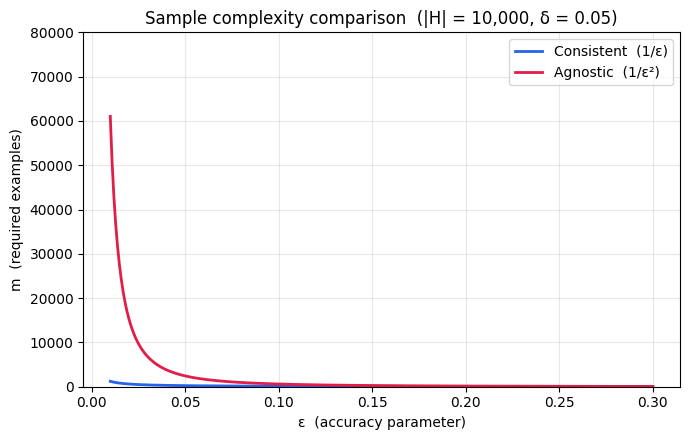

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))

epsilons = np.linspace(0.01, 0.3, 300)
delta, H_size = 0.05, 10_000

ax.plot(epsilons, sample_bound_consistent(epsilons, delta, H_size),
        label="Consistent  (1/ε)", color="#2563eb", linewidth=2)
ax.plot(epsilons, sample_bound_agnostic(epsilons, delta, H_size),
        label="Agnostic  (1/ε²)", color="#e11d48", linewidth=2)
ax.set_xlabel("ε  (accuracy parameter)")
ax.set_ylabel("m  (required examples)")
ax.set_title(f"Sample complexity comparison  (|H| = {H_size:,}, δ = {delta})")
ax.legend()
ax.set_ylim(0, 80_000)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Bias–Variance Tradeoff

We can solve the previous inequality for the threshold to obtain:

$\displaystyle \varepsilon \ge \sqrt{\frac{1}{2m}\left(\ln|H|+\ln\frac{1}{\delta}\right)}$

In Python:

In [9]:
def generalization_gap(m, delta, H_size):
    return np.sqrt((np.log(H_size) + np.log(1 / delta)) / (2 * m))

Therefore, with probability at least $1-\delta$, the true error of the empirically best hypothesis is at most:

$\displaystyle e_D(h) \le e_T(h) + \sqrt{\frac{1}{2m}\left(\ln|H|+\ln\frac{1}{\delta}\right)}$

This bound captures a fundamental tension in learning theory, commonly referred to as the **bias–variance tradeoff**:

- The first term is the **empirical error**. It measures how well the selected hypothesis fits the observed training data. This term can be made small by choosing a sufficiently expressive (rich) hypothesis space H.
- The second term is the **complexity penalty**. It depends on the size of the hypothesis space H and decreases as the number of training examples m increases.
This term quantifies the risk of overfitting due to limited data and model complexity.

If H is very large, it is easier to find a hypothesis that fits the training data extremely well (low empirical error). However, the complexity term grows , reflecting **increased variance**: with many hypotheses to choose from, it becomes more likely that one fits the sample unusually well by chance. Conversely, if H is too small, the complexity term shrinks, **reducing variance**. But the hypothesis class may be too restrictive to approximate the true concept well, leading to large empirical error.  

The following plot illustrates this tradeoff visually. We fix the sample size and vary the size of the hypothesis space |H|:

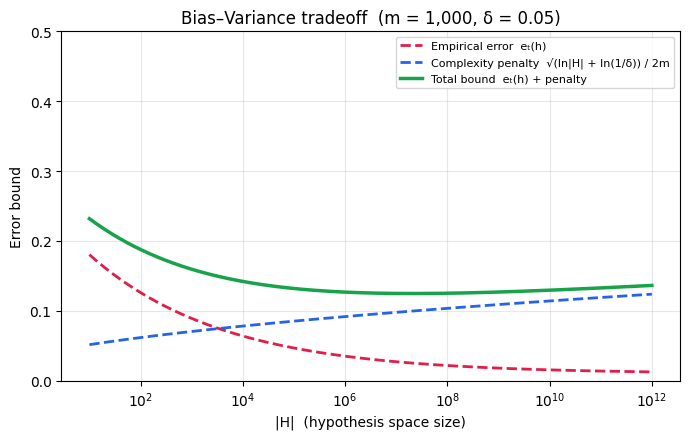

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))

m = 1000
delta = 0.05
H_sizes = np.logspace(1, 12, 300)

# Complexity penalty: grows with |H|
penalty = generalization_gap(m, delta, H_sizes)

# Empirical error: decreases as |H| grows (richer model fits better)
e_train = 0.25 * np.exp(-np.log(H_sizes) / 6) + 0.01

# Total bound
total = e_train + penalty

ax.plot(H_sizes, e_train, color="#e11d48", linewidth=2, linestyle="--",
        label="Empirical error  eₜ(h)")
ax.plot(H_sizes, penalty, color="#2563eb", linewidth=2, linestyle="--",
        label="Complexity penalty  √(ln|H| + ln(1/δ)) / 2m")
ax.plot(H_sizes, total, color="#16a34a", linewidth=2.5,
        label="Total bound  eₜ(h) + penalty")

ax.set_xlabel("|H|  (hypothesis space size)")
ax.set_ylabel("Error bound")
ax.set_xscale("log")
ax.set_title(f"Bias–Variance tradeoff  (m = {m:,}, δ = {delta})")
ax.legend(fontsize=8)
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The bias–variance tradeoff is the fundamental tension between **underfitting** and **overfitting**. It highlights the importance of choosing an appropriate level of model complexity relative to the amount of available data. This theoretical perspective sheds light on a widely used practical technique: **regularization**. In the bound above, the complexity penalty grows with the size of the hypothesis space. One way to reduce this penalty, without changing the architecture of the model, is to **restrict which hypotheses the learner is effectively allowed to use**. This is precisely what regularization does. For example, consider a linear classifier with real-valued weights. The full hypothesis space includes all possible weight vectors, but if we add an L2 penalty to the training objective, the learner is discouraged from choosing hypotheses with large weights. In effect, the optimization is constrained to a smaller region of the hypothesis space, a ball of bounded radius in weight space. The hypotheses in this restricted region are "simpler" in a precise sense: they correspond to smoother, less extreme decision boundaries. From the perspective of our bound, this means that **the effective size of the hypothesis space shrinks**, and consequently the complexity penalty decreases. The price is that the empirical error may increase slightly, because the learner can no longer fit the training data as aggressively. But this is exactly the tradeoff predicted by the bound: **by accepting a small increase in training error, we obtain a tighter control on the gap between training and generalization performance**. Cross-validation can then be understood as a practical method for tuning the strength of regularization, searching for the point where the sum of empirical error and complexity penalty is minimized without having access to the true generalization error.

Now that we have a bound indicating the number of training examples sufficient to probably approximately learn the target concept, we can use it to determine the sample complexity and PAC-learnability of some specific concept classes.

### Conjunctions of boolean literals

Consider learning the concept class of conjunctions of at most n boolean literals: 

$\displaystyle x_1, x_2, \ldots, x_n$

where a boolean literal is either a boolean variable or its negation, and a conjunction is simply a logical AND of some of these literals. If n=4, an example of conjunction can be:

$\displaystyle x_1 \> \cdot \> \bar{x}_2  \> \cdot \> x_4$

A **positive example** is any assignment that satisfies all the required literals. For instance:

$\displaystyle x_1 = 1, x_2 = 0, x_3 = 0, x_4 = 1$

A **negative example** violates at least one required literal. For example:

$\displaystyle x_1 = 1, x_2 = 0, x_3 = 1, x_4 = 0$

This concept class is particularly useful for understanding sample complexity because the hypothesis space is finite and the learner’s task is essentially to determine which literals are required. Positive examples help eliminate literals that are inconsistent with observed assignments. Negative examples help identify which variables are essential for excluding certain patterns.

**Is it learnable?** In order to answer this question, first we need to show that any consistent learner will require only a polynomial number of training examples to learn any concept (using the bound), then we propose a specific algorithm that uses polynomial time per training example.

Consider a consistent learner whose hypothesis space H coincides with the concept class. From the earlier finite-class bound, the number of training examples sufficient to guarantee, with some probability, a true error under a certain threshold is:

$\displaystyle m \;\ge\; \frac{1}{\varepsilon} \left(\ln |H| + \ln \frac{1}{\delta}\right)$

Now consider the class of conjunctions of literals over n Boolean variables. For each variable, a hypothesis may:
- include $x_i$,
- include $\bar{x}_i$,
- ignore $x_i$

Thus each variable contributes three possibilities, so:

$\displaystyle |H| = 3^n$

Substituting this into the bound gives

$\displaystyle m \;\ge\; \frac{1}{\varepsilon} \left( n \ln 3 + \ln \frac{1}{\delta} \right)$

For example, if a consistent learner attempts to learn a target concept described by conjunctions of 10 boolean literals, and we desire a 0.95 probability that it will learn a hypothesis with error less than 0.1, then we need to randomly drawn a number of training examples:

$\displaystyle m \geq \frac{1}{0.1} \left( 10 \ln 3 + \ln \frac{1}{0.05} \right) = 140$

Now we need to specify an algorithm and show that it requires no more than polynomial computation per training example. We can observe that positive examples are highly informative. Suppose we see a positive example:

$b_1, b_2, \ldots, b_n$

- if $b_i = 1$, then the target concept cannot contain the literal $\bar{x}_i$,
- if $b_i = 0$, then the target cannot contain $x_i$

Thus, each positive example eliminates inconsistent literals. A simple algorithm is therefore:

1.	Start with the conjunction containing all possible literals
2.	For each positive example: 
		remove every literal contradicted by that example
3.  Output the conjunction of all remaining literals.

Each update requires scanning all n variables, so the time per example is O(n),hence the total running time is polynomial. Negative examples are not needed because positive examples alone eliminate all incompatible literals. The following figure shows an example for the case n=6:

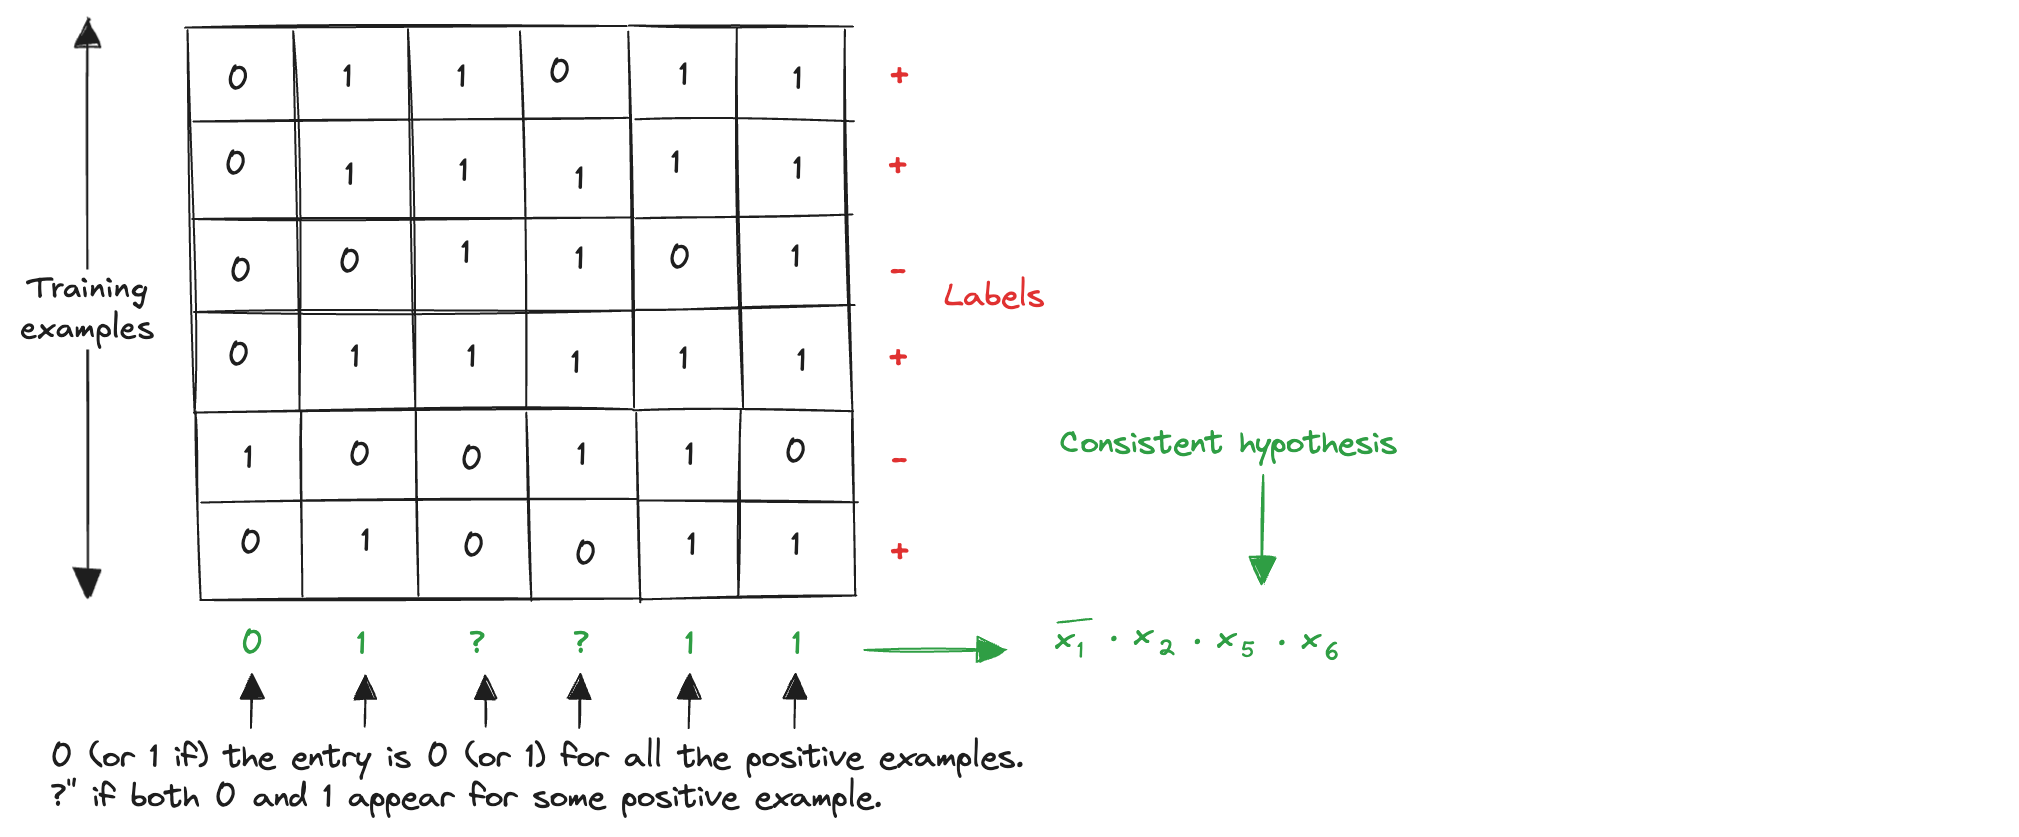

In conclusion, since the proposed algorithm requires no more than polynomial computation per training example, and all consistent learners requires no more than a polynomial number of training examples, then the total computation required will be polynomial as well and **the problem is learnable**. 

Of course, not all concept classes have polynomially bounded sample complexity and it is also possible to find concept classes that have polynomial sample complexity, but nevertheless cannot be learned in polynomial time because there is no polynomial time algorithm that can learn them.

### Universal concept class

Let us now consider a much more extreme example, which helps clarify what makes a concept class learnable and what makes it impossible to learn efficiently. Take the instance space to be the set of all Boolean vectors of length n:

$\displaystyle X = \{0,1\}^n$

An element of X is simply a binary string of length n. For example, when n=2, the instance space consists of the four possible binary pairs:

$\displaystyle X = \{00, 01, 10, 11\}$

In general, since each of the n coordinates can take two values, the total number of possible instances is:

$\displaystyle |X| = 2^n$

Now consider the concept class U comprising all possible subsets of X. In other words, every subset of X defines a valid concept. An instance is labeled positive if it belongs to the chosen subset, and negative otherwise. In the simple case n=2, the instance space has four elements. The concept class therefore consists of all subsets of these four elements:

$\displaystyle U_2 = \{ \}, \{00\}, \{01\}, \{10\}, \{11\},$

$\displaystyle \{00, 01\}, \{00, 10\}, \{00, 11\}, \{01, 10\}, \{01, 11\}, \{10, 11\},$

$\displaystyle \{00, 01, 10\}, \{00, 01, 11\}, \{00, 10, 11\}, \{01, 10, 11\},$

$\displaystyle \{00, 01, 10, 11\}$

There are 2^4 = 16 such subsets. More generally, the number of possible concepts is:

$\displaystyle |U_n| = 2^{|X|} = 2^{2^n}$

This class is enormous, its size grows doubly exponentially in n. Intuitively, U can represents the class of all possible labelings of the instance space. There is no structure, no restriction, no assumption about regularity. Every possible way of assigning 0/1 labels to the 2^n points in X is allowed. In other words, the class contains every conceivable Boolean function on n variables. Is this class learnable?

Using the finite hypothesis bound for consistent learning, the required number of training examples satisfies

$\displaystyle m \ge \frac{1}{\varepsilon} \left( \ln |H| + \ln \frac{1}{\delta}\right) = \frac{1}{\varepsilon} \left( \ln 2^{2^n} + \ln \frac{1 }{\delta}\right) = \frac{1}{\varepsilon} \left( 2^n \ln 2 + \ln \frac{1}{\delta}\right)$

This number of training examples grows exponentially in n and the concept class is not PAC-learnable.

This conclusion reflects **a fundamental limitation of learning**. The concept class U places **no restrictions** on how labels are assigned: every possible labeling of the instance space is permitted. In such a setting, there is simply **no regularity or pattern for the learner to discover**. If a particular instance x of X does not appear in the training sample, then its label is entirely unconstrained: it could be positive or negative under some concept in the class, and **nothing in the observed data provides guidance**. In the worst case, to identify the target concept with confidence, the learner would need to observe nearly every point in the instance space, but the space itself already grows exponentially with n, and so does the amount of data required.

This example highlights a central lesson of learning theory: **generalization is only possible when the hypothesis class imposes structure on the labeling function**. When the space of possible concepts is unrestricted, the learner cannot infer anything beyond the examples it has explicitly seen. If completely arbitrary labelings are allowed, then no sample size can ensure reliable prediction on unseen data. In short, structure is not merely convenient, it is **essential**.

## Complexity in infinite hypothesis spaces

In practice, most hypothesis spaces used in machine learning are **infinite**. Linear classifiers with real-valued weights, neural networks with continuous parameters, and many other common models all contain infinitely many possible hypotheses. In such cases, bounds that depend directly on the size of the hypothesis space are no longer meaningful, since:

$\displaystyle |H| = \infty$ 

However, infinity alone does not imply that a class is too complex to learn. What truly matters is not the number of hypotheses in an abstract sense, but how flexibly the hypothesis class can label finite sets of instances. This motivates a different notion of complexity, the [**Vapnik–Chervonenkis (VC) dimension**](./papers/(1989)%20-%20Learnability%20and%20the%20Vapnik-Chervonenkis%20dimension.pdf), which measures the expressive power of a hypothesis class by examining how many points in the instance space it can classify in all possible ways.

### Shattering a Set of Instances

When the hypothesis space is infinite, we need a different way to measure its complexity than simply counting how many hypotheses it contains. Instead of asking how many distinct functions are in H, we ask **how flexibly** the hypotheses in H can **discriminate** between instances in the input space. In other words, we want to understand how many different **labeling patterns** the hypothesis space can express. To formalize this idea, we introduce the notion of **shattering**. Consider a finite subset of instances

$\displaystyle S \subseteq X$ 

Each hypothesis h in H assigns a binary label to every instance in S, thereby partitioning the set into two groups: those labeled positive and those labeled negative. Such a labeling of the points in S is called a **dichotomy**. If the set S contains |S| instances, then there are

$\displaystyle 2^{|S|}$ 

possible ways to assign binary labels to them. Intuitively, each of these labelings represents a different way of separating the points in S into two classes. The question is whether the hypotheses in H are **expressive enough** to realize all of them.

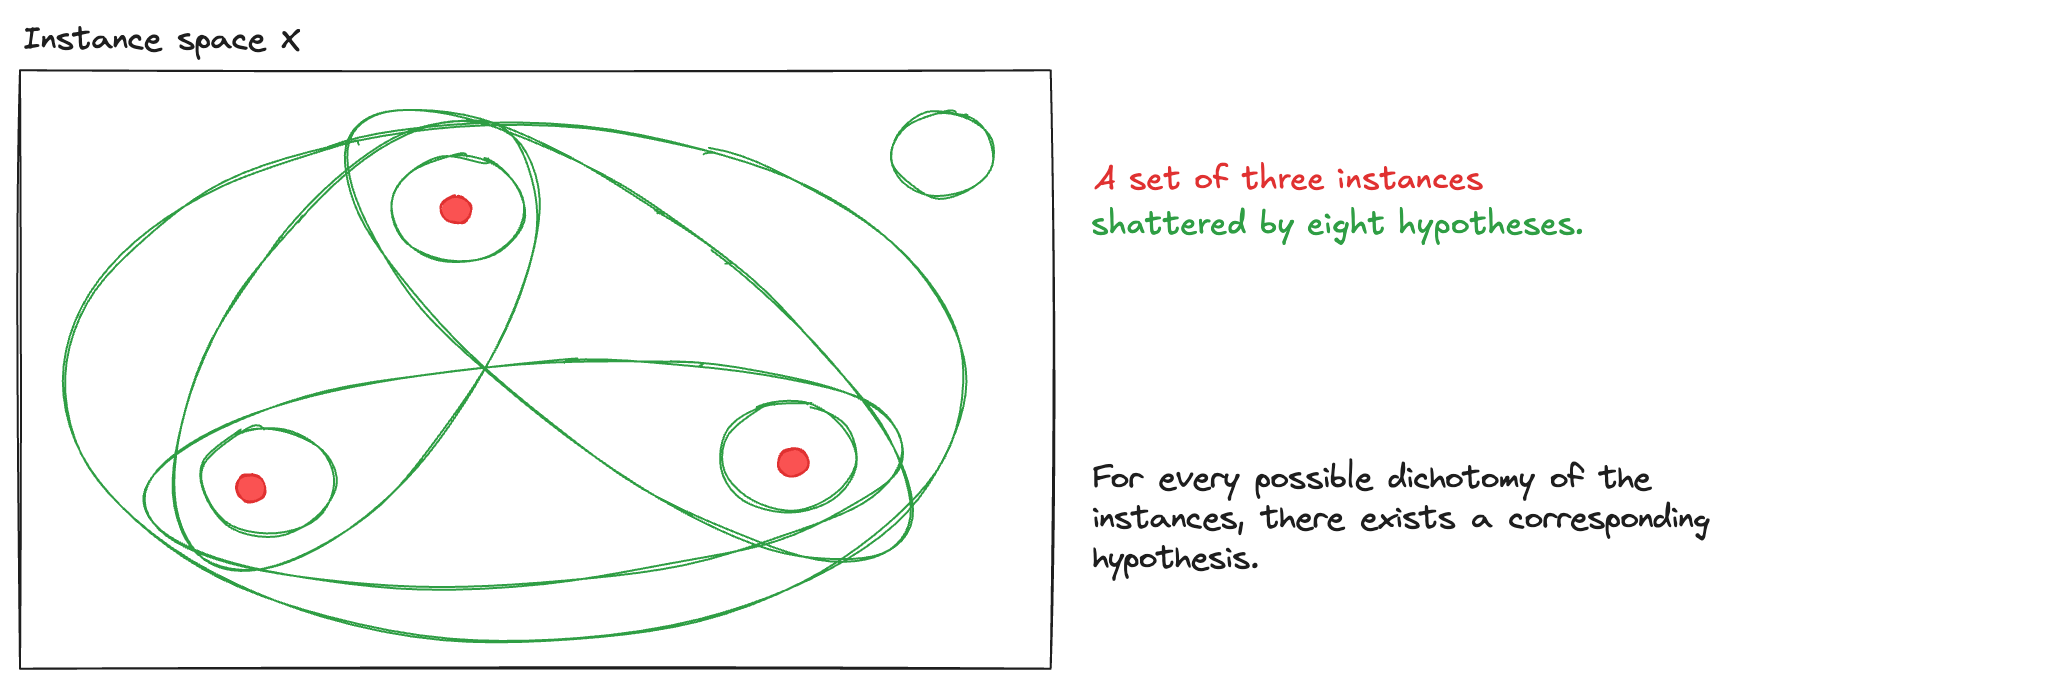

For example, imagine that the instances in X are points on a plane and that H is the set of linear classifiers (straight lines). If we take three points in general position (not colinear), we can label them in every possible way using different lines: for each labeling, there exists some line that separates the positive points from the negative ones. In this case, the hypothesis class is expressive enough to realize all labelings of those three points:

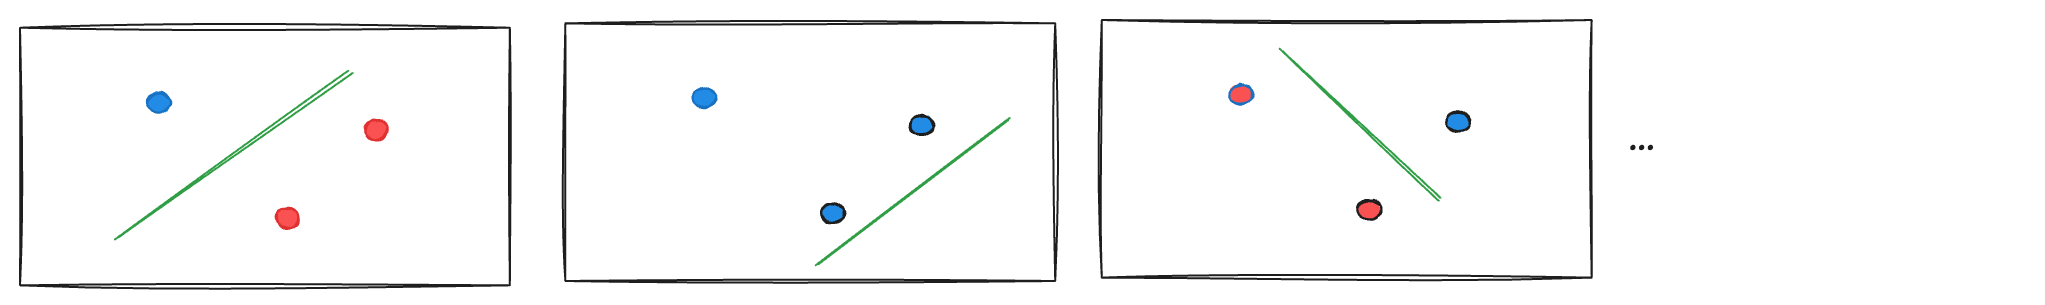

A given hypothesis space may not be able to represent all of these labelings, some patterns of labels might simply be **impossible** to produce for the hypotheses of that space. If we take four points arranged in a square, something different happens. There is a particular labeling pattern (where opposite corners have the same label) that no straight line can represent. In this case, the hypothesis class cannot realize all possible dichotomies of those four points:

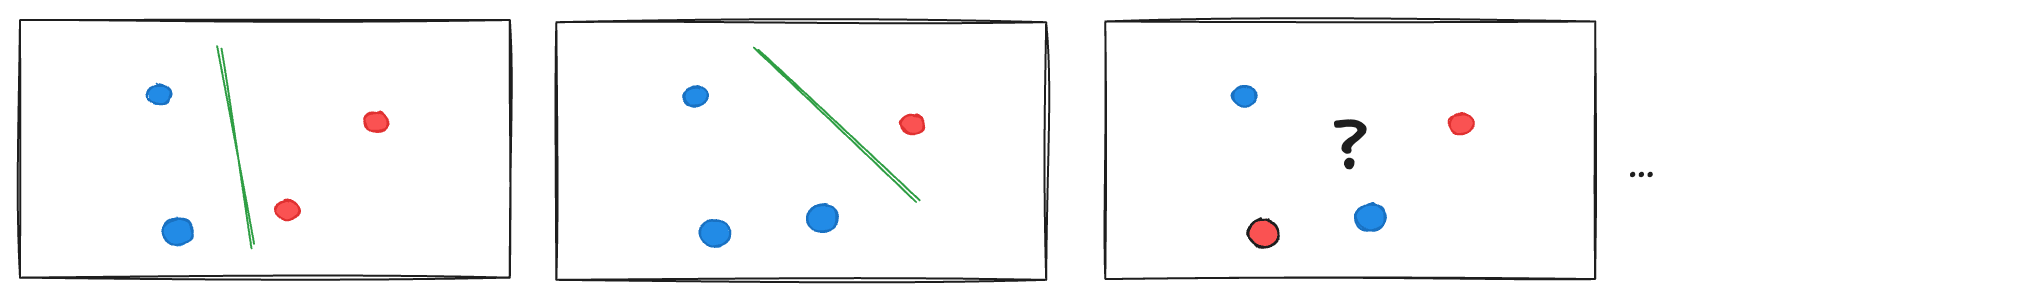

We say that the hypothesis space **shatters** the set S if it is **powerful enough to realize every possible labeling** of the points in S. That is, for every assignment of binary labels to the instances in S, there exists some hypothesis h in H that classifies the points exactly according to that labeling. If a set of instances cannot be shattered by H, then there exists at least one labeling of those instances that cannot be represented by any hypothesis in the class. 

### The Vapnik–Chervonenkis Dimension

The notion of shattering helps us understand how expressive a hypothesis space is. If a hypothesis space can shatter a set of instances, it means that it is **flexible enough** to realize every possible labeling of those instances. **The larger the sets that can be shattered, the more expressive the hypothesis space is**.

This idea is closely related to the **inductive bias** concept. A learning algorithm must choose hypotheses from some restricted hypothesis space H. This restriction **implicitly encodes assumptions** about the kinds of patterns that can occur in the data. For example, if H consists of linear classifiers, the learner assumes that the target concept can be separated by a line (or hyperplane). If H consists of conjunctions of Boolean variables, the learner assumes the concept can be expressed as a conjunction of conditions. In general, the hypothesis space limits which labelings of the data can be represented. These assumptions are called the inductive bias of the learner.

If a hypothesis space were able to represent every possible labeling of the instance space, it would have **no bias at all**. In the language introduced earlier, this would mean that the hypothesis space could shatter the entire instance space. Such a hypothesis space would be **extremely expressive**, but **it would also make learning impossible from limited data**, because every labeling would remain plausible.

To measure the expressive power more precisely, we introduce the Vapnik–Chervonenkis (VC) dimension of an hypothesis space H as **the size of the largest finite subset that can be shattered** by H. If sets of arbitrarily large size can be shattered, then

$\displaystyle \text{VC}(H) = \infty$

Thus the VC dimension measures how many instances can be arranged so that the hypothesis space can represent every possible labeling of them. A larger VC dimension corresponds to a more expressive hypothesis space. There is a simple relationship between the VC dimension and the size of a finite hypothesis space. If H is finite, then

$\displaystyle \text{VC}(H) \le \log_2 |H|$

To see this, suppose that 

$\displaystyle \text{VC} = d$ 

Then there exists a set of d instances that can be shattered by H. Shattering requires that all 2^d possible labelings of these d instances can be represented by hypotheses in H. Therefore the hypothesis space must contain at least 2^d distinct hypotheses. Hence

$\displaystyle 2^d \le |H|$

Taking logarithms gives

$\displaystyle d \le \log_2 |H|$

### Bounds using the VC dimension

Using the VC dimension instead of |H|, it is possible to derive a new bound on the number of training examples required for learning: 

$\displaystyle m \ge \frac{1}{\varepsilon} \left( 4 \log_2 \frac{2}{\delta} + 8 \text{VC}(H) \log_2 \frac{13}{\varepsilon} \right)$

In Python:

In [19]:
def vc_bound(epsilon, delta, vc_dim):
    return (1 / epsilon) * (4 * np.log2(2 / delta) +
                             8 * vc_dim * np.log2(13 / epsilon))

This bound shows that the number of examples sufficient to guarantee PAC learning depends on the VC dimension of the hypothesis space rather than on its cardinality. An important observation is that the **qualitative behavior of the bound remains similar to the earlier finite-case bound**. The required number of training examples still grows logarithmically in $1/\delta$ (the confidence parameter), meaning that increasing the desired confidence only mildly increases the sample size. The dependence on the accuracy parameter $\varepsilon$ is also similar, although the precise form of the bound changes slightly. The crucial difference is that the logarithm of the size of the hypothesis space appearing in the earlier bound is now replaced by the VC dimension. Recall that for any finite hypothesis space:

$\displaystyle \text{VC}(H) \le \log_2 |H|$

so VC dimension can be viewed as a **more refined and often much smaller measure of complexity**. Even when H is infinite, the VC dimension may still be finite, allowing meaningful learning guarantees to be derived.

We can now explore this bound numerically and compare it with the earlier finite-class bound. The following code evaluates it for several representative hypothesis spaces:

In [30]:
# --- Numerical examples for different hypothesis spaces ---
print("=== VC-based sample complexity ===\n")
print(f"{'Hypothesis space':>30}  {'VC':>4}  {'ε':>6}  {'m (upper)':>10}")
print("-" * 58)

examples = [
    ("Lines in R²", 3),
    ("Hyperplanes in R¹⁰", 11),
    ("Hyperplanes in R¹⁰⁰", 101),
]

for name, vc in examples:
    for eps in [0.1, 0.05, 0.01]:
        m_up = vc_bound(eps, 0.05, vc)
        print(f"{name:>30}  {vc:>4}  {eps:>6}  {m_up:>10,.0f}")
    print()



=== VC-based sample complexity ===

              Hypothesis space    VC       ε   m (upper)
----------------------------------------------------------
                   Lines in R²     3     0.1       1,898
                   Lines in R²     3    0.05       4,276
                   Lines in R²     3    0.01      26,955

            Hyperplanes in R¹⁰    11     0.1       6,393
            Hyperplanes in R¹⁰    11    0.05      14,545
            Hyperplanes in R¹⁰    11    0.01      93,159

           Hyperplanes in R¹⁰⁰   101     0.1      56,954
           Hyperplanes in R¹⁰⁰   101    0.05     130,067
           Hyperplanes in R¹⁰⁰   101    0.01     837,948



The following plot shows how the VC-based bound grows as a function of ε for three hypothesis spaces with different VC dimensions. On a logarithmic scale, the curves are well separated, illustrating how a higher VC dimension systematically requires more training examples at every accuracy level:

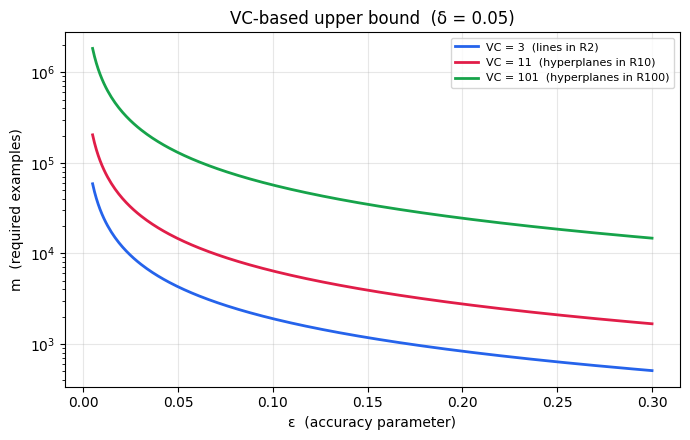

In [31]:
fig, ax = plt.subplots(figsize=(7, 4.5))

epsilons = np.linspace(0.005, 0.3, 300)
delta = 0.05

for vc, color, label in [(3, "#2563eb", "VC = 3  (lines in R2)"),
                          (11, "#e11d48", "VC = 11  (hyperplanes in R10)"),
                          (101, "#16a34a", "VC = 101  (hyperplanes in R100)")]:
    m_up = vc_bound(epsilons, delta, vc)
    ax.plot(epsilons, m_up, color=color, linewidth=2, label=label)

ax.set_xlabel("ε  (accuracy parameter)")
ax.set_ylabel("m  (required examples)")
ax.set_title("VC-based upper bound  (δ = 0.05)")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


It is worth noting that when the hypothesis space is finite, the earlier bound based on |H| can yield a tighter numerical guarantee than the VC-based bound, because its constants are smaller. However, this comparison misses the essential point. The finite bound **requires** |H| to be a well-defined finite number, and it becomes meaningless as soon as the hypothesis space is infinite. The VC-based bound, by contrast, provides meaningful guarantees whenever the VC dimension is finite, **regardless of whether the hypothesis space itself is finite or infinite**. This is precisely the situation encountered in practice with linear classifiers, neural networks, and most other parametric models: |H| is infinite, but VC(H) is finite, and only the VC-based bound can be applied.

## Artificial Neural Networks

Considering artificial neural networks, it is natural to ask how the complexity of a neural network hypothesis space can be characterized using the VC dimension. In particular, we would like to understand how [the expressive power of a feedforward neural network grows with the number of units it contains](./papers/(1989)%20-%20What%20Size%20Net%20Gives%20Valid%20Generalization.pdf). 

### Directed acyclic graph

Consider a neural network G whose units are arranged in layers forming a **directed acyclic graph**. "Directed" means that connections have a direction (from inputs toward the output), and "acyclic" means that there are no feedback loops: information always flows forward through the network. Feedforward neural networks trained with backpropagation are examples of such layered acyclic structures. Suppose the network has n input nodes and s internal computational units. Each internal unit receives at most r inputs and implements a Boolean-valued function drawn from some concept class C with VC dimension d:

$\displaystyle C = \{c: \{0,1\}^r \to \{0,1\}\}$

For example, if the internal units are perceptrons, then each unit computes a linear threshold function over its inputs:

$\displaystyle c(x) = \mathbf{1}_{\{w \cdot x + b > 0\}}$

We can view the entire network as **composing** these individual units together.The functions representable by the whole network therefore form a new hypothesis space $C_G$. Intuitively, this is simply **the class of functions that the network architecture G can implement when each node is allowed to use functions from the class C**. A key result shows that the VC dimension of this network can be bounded using two quantities: the **VC dimension of the individual units d**, and the **number of such units in the network s**:

$\displaystyle \text{VC}(C_G) \le 2ds \log(es)$

This result shows that **the expressive power of the network grows almost linearly with the number of units**, with only an additional logarithmic correction factor.

### Perceptron

Consider the class of linear classifiers in a two-dimensional plane, we have seen that if the three points are not colinear, they can be shattered. No matter how we assign binary labels to the three points, we can always draw a line that separates the positively labeled points from the negatively labeled ones. Since all 2^3=8 possible labelings can be realized, any non-colinear set of three points is shattered by H. Of course, not every set of three points works. If the three points lie on a single line, then some labelings become impossible. But this does not matter for the VC dimension. It is enough to exhibit one set of three points that can be shattered, and three non-colinear points provide such an example. So we can conclude that the VC dimension of linear classifiers in two dimensions is at least three:

$\displaystyle \text{VC}(H) \ge 3$

The next question is whether four points can be shattered. Here the answer is no. No matter how we place four points in the plane, there will always be at least one labeling that cannot be realized by a single straight line: if we label two opposite corners positive and the other two negative, no straight line can separate the two classes. So no set of four points can be shattered. This establishes that the VC dimension of linear classifiers in two dimensions is exactly three:

$\displaystyle \text{VC}(H) = 3$

This result shows that the VC dimension provides a more refined measure of hypothesis space complexity. Even when the hypothesis space is infinite, its VC dimension may still be finite, allowing meaningful learning guarantees to be derived. More generally, it can be shown that the VC dimension of linear decision surfaces in an r dimensional space (i.e., the VC dimension of a
perceptron with r inputs) is r+1.

### Complexity

We can substitute the complexity of the single perceptron into the earlier bound for the whole network in order to obtain a bound on the VC dimension of an artificial neural network:

$\displaystyle \text{VC}(\text{ANN}) \le 2(r+1)s\log(es)$

Thus **the capacity of a neural network grows with both the number of units s and the number of inputs per unit r**. In simple terms, adding more neurons or increasing the dimensionality of their inputs increases the range of functions the network can represent. Once we know the VC dimension of the hypothesis space represented by the network, we can plug this quantity into the general PAC sample complexity bounds. Doing so yields an upper bound on the number of training examples m sufficient to learn the network with a defined accuracy and confidence:

$\displaystyle m \ge \frac{1}{\varepsilon} \left( 4 \log_2 \frac{2}{\delta} + 16(r+1)s\log(es) \log_2 \frac{13}{\varepsilon} \right)$

The key message is that **larger networks require more data to learn reliably, because their hypothesis spaces are more expressive**. However, this theoretical bound does not perfectly capture how neural networks are trained in practice. First, the result applies to networks of perceptrons, whereas modern networks often use sigmoid or other smooth activation functions. Fortunately, sigmoid units can approximate perceptrons arbitrarily well, so their VC dimension cannot be smaller. Second, the analysis assumes that every hypothesis representable by the network is equally likely to be found by the learning algorithm. In practice, training algorithms such as backpropagation introduce additional biases. For example, training typically starts with weights close to zero and adjusts them gradually, and techniques such as early stopping favor solutions with relatively small weights. These biases effectively restrict the region of the hypothesis space that the learner explores, reducing the effective capacity of the network. In other words, although the theoretical VC bound describes the maximum expressive power of the network architecture, the functions actually learned in practice often come from a much smaller and more structured subset of this space.

## Modern perspectives on generalization

The VC-based analysis predicts that a network with many more parameters than training examples should overfit catastrophically: the hypothesis space is so vast that the learner could memorize the training set without capturing any genuine pattern. Yet in practice, modern deep networks routinely operate in this **overparameterized regime** (millions or even billions of parameters trained on comparatively smaller datasets) and **still generalize remarkably wel**l. This phenomenon, sometimes called the ["**double descent" curve**](./papers/(2019)%20-%20Reconciling%20modern%20machine%20learning%20practice%20and%20the%20bias-variance%20trade-off.pdf), challenges the classical bias–variance picture. The bound we derived above tells us that generalization can be guaranteed when the sample size is large relative to the VC dimension, but it does not explain why generalization still occurs when this condition is violated. Several lines of recent research attempt to bridge this gap. Some focus on the role of the optimization algorithm itself: stochastic gradient descent, combined with common initialization schemes, appears to **implicitly favor "simple" solutions** even within an enormous hypothesis space, a phenomenon often called implicit regularization. Others study norm-based or compression-based complexity measures that capture the actual functions learned by the network rather than all functions the architecture could in principle represent. Still others investigate the geometry of the loss landscape and the peculiar behavior of interpolating models. As of today, a complete and unified theoretical explanation remains an active area of research. The classical VC theory presented here is therefore best understood as a foundational starting point: it gives the right conceptual vocabulary (capacity, sample complexity, the tension between expressiveness and generalization) and provides rigorous guarantees in well-defined settings, but the full story of why deep learning works as well as it does is still being written.